## Paul Ng
## MSDS 689-01
## Group 3
## Group Assignment Task 2

In [1]:
from pyspark import SparkConf, SparkContext
import pyspark

sc = pyspark.SparkContext(appName="paul").getOrCreate()
sc.setLogLevel("ERROR")


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/02 17:53:00 WARN Utils: Your hostname, Ignacios-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 10.0.0.231 instead (on interface en0)
25/12/02 17:53:00 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/02 17:53:00 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
import argparse

parser = argparse.ArgumentParser()
parser.add_argument(
    "--is-local",
    type=str,
    default="true",
    help="Whether running in local mode",
)

args, unknown = parser.parse_known_args()
is_local = args.is_local.lower() == "true"
if is_local:
    prefix = "../data/processed/merged"
else:
    prefix = "gs://msds-694-cohort-14-3/data"

print(f"Is local environment: {is_local}")

num_csv_path = f"{prefix}/num_2020.csv"
pre_csv_path = f"{prefix}/pre_2020.csv"
sub_csv_path = f"{prefix}/sub_2020.csv"
tag_csv_path = f"{prefix}/tag_2020.csv"

print(f"Num CSV path: {num_csv_path}")
print(f"Pre CSV path: {pre_csv_path}")
print(f"Sub CSV path: {sub_csv_path}")
print(f"Tag CSV path: {tag_csv_path}")

num_rdd = sc.textFile(num_csv_path)
pre_rdd = sc.textFile(pre_csv_path)
sub_rdd = sc.textFile(sub_csv_path)
tag_rdd = sc.textFile(tag_csv_path)

# print size of each RDD
print(f"Num RDD size: {num_rdd.count()}")
print(f"Pre RDD size: {pre_rdd.count()}")
print(f"Sub RDD size: {sub_rdd.count()}")
print(f"Tag RDD size: {tag_rdd.count()}")

Is local environment: True
Num CSV path: ../data/processed/merged/num_2020.csv
Pre CSV path: ../data/processed/merged/pre_2020.csv
Sub CSV path: ../data/processed/merged/sub_2020.csv
Tag CSV path: ../data/processed/merged/tag_2020.csv


Num RDD size: 11493263
Pre RDD size: 2746310
Sub RDD size: 24940
Tag RDD size: 298803


In [3]:
# num_rdd.glom().collect()

#### Splitting the data

In [4]:
num_rdd = num_rdd.map(lambda x: x.split(","))

#### Removing the first row in the dataset (header)

In [5]:
header = num_rdd.first()
num_data = num_rdd.filter(lambda line: line != header)

In [ ]:
# num_data.collect()

25/12/02 17:53:04 ERROR TransportResponseHandler: Still have 2 requests outstanding when connection from /10.0.0.231:56768 is closed
25/12/02 17:53:04 ERROR Executor: Exception in task 6.0 in stage 5.0 (TID 69)
java.lang.OutOfMemoryError: Java heap space
25/12/02 17:53:04 ERROR Executor: Exception in task 11.0 in stage 5.0 (TID 74)
java.lang.OutOfMemoryError: Java heap space
25/12/02 17:53:04 ERROR OneForOneBlockFetcher: Failed while starting block fetches
java.io.IOException: Connection from /10.0.0.231:56768 closed
	at org.apache.spark.network.client.TransportResponseHandler.channelInactive(TransportResponseHandler.java:151)
	at org.apache.spark.network.server.TransportChannelHandler.channelInactive(TransportChannelHandler.java:120)
	at io.netty.channel.AbstractChannelHandlerContext.invokeChannelInactive(AbstractChannelHandlerContext.java:303)
	at io.netty.channel.AbstractChannelHandlerContext.invokeChannelInactive(AbstractChannelHandlerContext.java:281)
	at io.netty.channel.Abstract

ConnectionRefusedError: [Errno 61] Connection refused

ConnectionRefusedError: [Errno 61] Connection refused

#### Metrics for Company Net Earnings

Based on an exploration of the Financial Statement Data Sets, to determine the net income of a given company reported quarterly, the tags "NetIncomeLoss" and "ProfitLoss" will be used. In the dataset, there are more specific variants of "NetIncomeLoss", including:

- NetIncomeLossAvailableToCommonStockholdersBasic

- NetIncomeLossAvailableToCommonStockholdersDiluted

- NetIncomeLossFromContinuingOperationsAvailableToCommonShareholdersBasic

- NetIncomeLossFromContinuingOperationsAvailableToCommonShareholdersDiluted

- NetIncomeLossAttributableToNoncontrollingInterest

However, these can be thought of as subcomponents of net income and thus is not all-inclusive. To explore earnings of companies, the tag "NetIncomeLoss" will be used since it represents the overall earnings for the company.

There are also Earnings Per Share (EPS) metrics in the dataset, which could be interesting to explore and compare.


In [ ]:
earnings_tags = ["NetIncomeLoss", "ProfitLoss"]

For this part of the project, we split the data up into chunks to run locally. The chunk of data that we are using contains 10,000 rows which only contains quarter 1 (Q1) data. I will look at how many companies are profitable and non-profitable in Q1 using the "NetIncomeLoss" and "ProfitLoss" tags. This can be extended to include all quarters for the final deliverable.

#### Filtering data with "NetIncomeLoss" and "ProfitLoss" tags

The format of the num dataset is as follows:

0 = adsh

1 = tag

2 = version

3 = ddate

4 = qtrs

5 = uom

6 = segments

7 = coreg

8 = value

9 = footnote

10 = quarter

11 = year

In [ ]:
earnings_rdd = (
    num_data.filter(lambda row: row[1] in earnings_tags)
    .filter(lambda row: row[5] == "USD")
    .filter(lambda row: row[4] == "1")
    .filter(lambda row: row[8] not in ("", "NaN", "nan"))
)


In [ ]:
earnings_rdd.take(5)

[['0001572758-20-000018',
  'NetIncomeLoss',
  'us-gaap/2019',
  '20180930',
  '1',
  'USD',
  '',
  '',
  '3209000.0',
  '',
  'q1',
  '2020'],
 ['0000821026-20-000011',
  'ProfitLoss',
  'us-gaap/2019',
  '20190930',
  '1',
  'USD',
  '',
  '',
  '-5870000.0',
  '',
  'q1',
  '2020'],
 ['0001564590-20-009164',
  'NetIncomeLoss',
  'us-gaap/2019',
  '20180930',
  '1',
  'USD',
  '',
  '',
  '8997000.0',
  '',
  'q1',
  '2020'],
 ['0001628280-20-003720',
  'NetIncomeLoss',
  'us-gaap/2019',
  '20180930',
  '1',
  'USD',
  '',
  '',
  '-45120000.0',
  '',
  'q1',
  '2020'],
 ['0001061219-20-000014',
  'ProfitLoss',
  'us-gaap/2019',
  '20180630',
  '1',
  'USD',
  '',
  '',
  '687200000.0',
  '',
  'q1',
  '2020']]

In [ ]:
earnings_by_filing = earnings_rdd.map(
    lambda row: (
        (row[11], row[10], row[0]),  # key: (year, quarter, adsh)
        float(row[8]),  # value: net income
    )
)

In [ ]:
earnings_by_filing.take(5)

[(('2020', 'q1', '0001572758-20-000018'), 3209000.0),
 (('2020', 'q1', '0000821026-20-000011'), -5870000.0),
 (('2020', 'q1', '0001564590-20-009164'), 8997000.0),
 (('2020', 'q1', '0001628280-20-003720'), -45120000.0),
 (('2020', 'q1', '0001061219-20-000014'), 687200000.0)]

In [ ]:
earnings_by_filing.count()

110

The above is now a paired RDD, with the key being a tuple of ("year","quarter #", "adsh ID") and the value being the "net income". Using Pair RDD will allow me to use reduceByKey, to combine any duplicates.

In [ ]:
earnings_by_filing = earnings_by_filing.reduceByKey(lambda x, y: x + y)

In [ ]:
earnings_by_filing.count()

104

In [ ]:
profitable_companies = earnings_by_filing.map(
    lambda x: ((x[0][0], x[0][1]), (1 if x[1] > 0 else 0))
)

In [ ]:
profitable_companies.take(5)

[(('2020', 'q1'), 0),
 (('2020', 'q1'), 1),
 (('2020', 'q1'), 1),
 (('2020', 'q1'), 1),
 (('2020', 'q1'), 1)]

#### Number of Profitable Companies

In [ ]:
profitable_companies.reduceByKey(lambda x, y: x + y).map(
    lambda x: x[1]
).collect()

[62]

Since the total number of companies that had an earnings_tag was 104, about 59.6% of companies reported a positive net income in Q1 of 2020

#### Visualization

The chart below shows a plot of all the reported Net Income for all unique adsh IDs in the first 10,000 rows of the dataset (only containing Q1 data).

In [ ]:
# Make RDD into Python list for plotting
earnings_list = earnings_by_filing.collect()

# Sorting the net income
earnings_list.sort(key=lambda x: x[1])

In [ ]:
earnings_list

[(('2020', 'q1', '0001564590-20-005038'), -4295900000.0),
 (('2020', 'q1', '0000075679-20-000002'), -767721000.0),
 (('2020', 'q1', '0001451505-20-000020'), -242000000.0),
 (('2020', 'q1', '0001193125-20-044221'), -176000000.0),
 (('2020', 'q1', '0001300514-20-000011'), -170000000.0),
 (('2020', 'q1', '0001564590-20-007447'), -74912000.0),
 (('2020', 'q1', '0001104659-20-026203'), -45730000.0),
 (('2020', 'q1', '0001628280-20-003720'), -45120000.0),
 (('2020', 'q1', '0000874501-20-000034'), -43000000.0),
 (('2020', 'q1', '0001558370-20-002573'), -24806984.0),
 (('2020', 'q1', '0000851310-20-000006'), -11306000.0),
 (('2020', 'q1', '0001564590-20-010261'), -11165000.0),
 (('2020', 'q1', '0001047469-20-001338'), -7131000.0),
 (('2020', 'q1', '0001558370-20-001789'), -6892000.0),
 (('2020', 'q1', '0001564590-20-004274'), -6664857.0),
 (('2020', 'q1', '0001564590-20-013670'), -6356404.0),
 (('2020', 'q1', '0001558370-20-001763'), -5988000.0),
 (('2020', 'q1', '0000821026-20-000011'), -5870

In [ ]:
# Grab adsh IDs
filing_ids = [x[0][2] for x in earnings_list]

# Grab net income values
net_incomes = [x[1] for x in earnings_list]

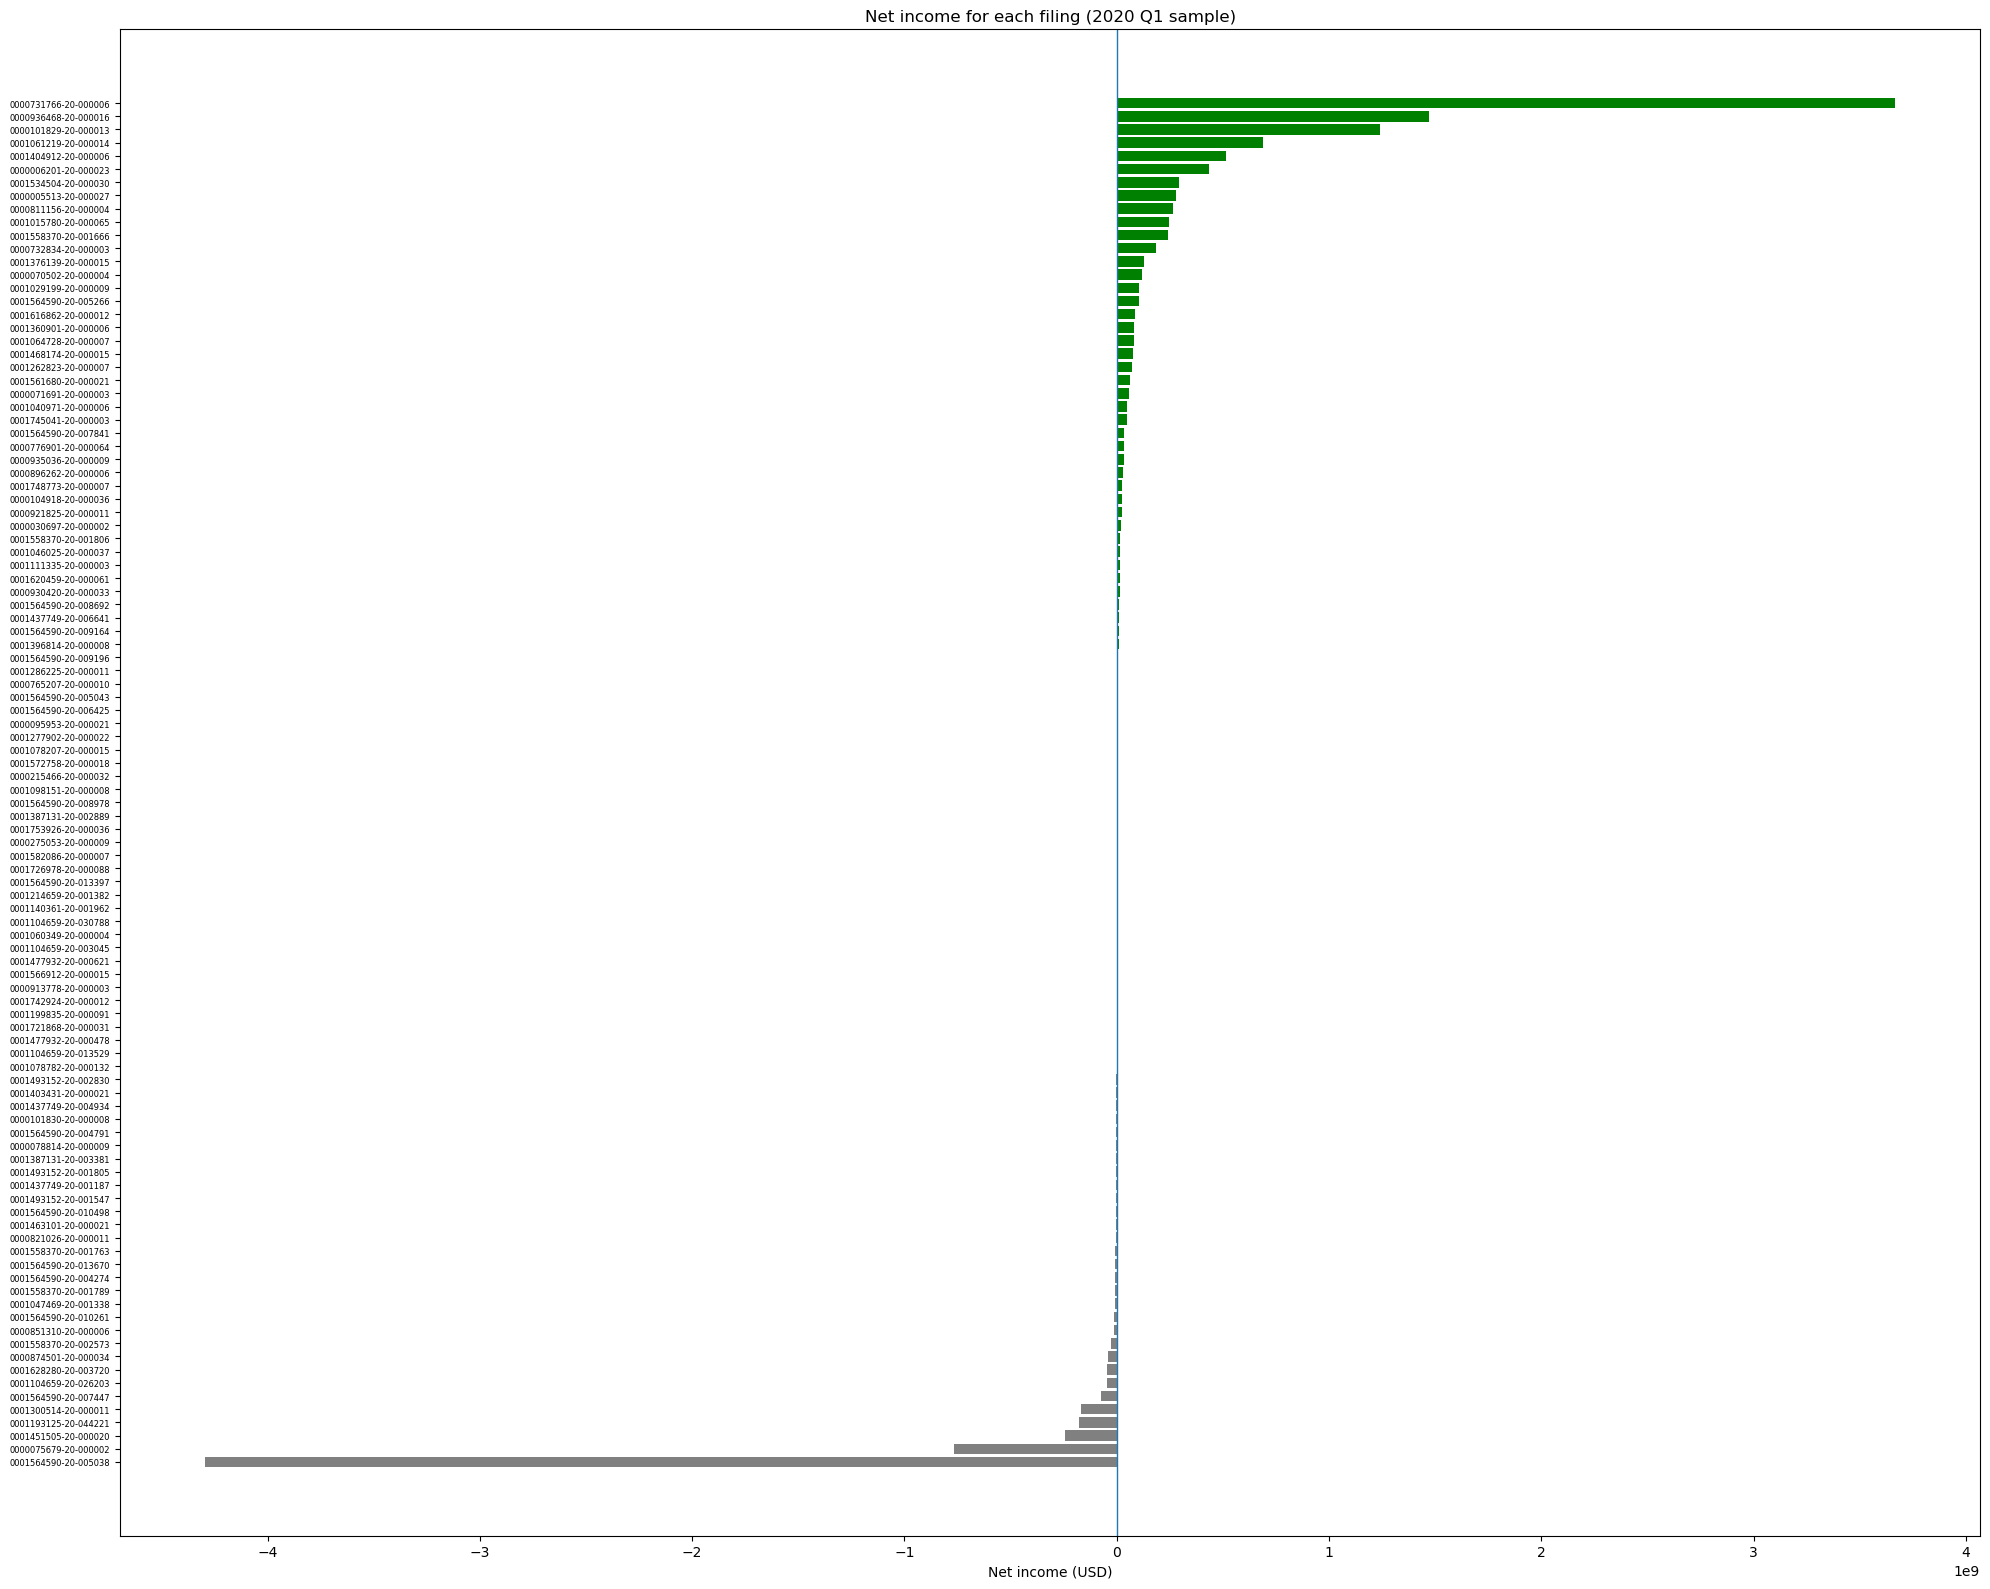

In [ ]:
import matplotlib.pyplot as plt

# 1. Collect & (optionally) sort by net income
earnings_list = earnings_by_filing.collect()
earnings_list.sort(
    key=lambda x: x[1]
)  # smallest losses at bottom, biggest profits at top

# 2. Build labels (adsh IDs) and values
filing_ids = [item[0][2] for item in earnings_list]  # adsh
net_incomes = [item[1] for item in earnings_list]

# 3. Choose colors: green for positive, grey for negative/zero
colors = ["green" if v > 0 else "grey" for v in net_incomes]

# 4. Horizontal bar chart
plt.figure(figsize=(20, 16))

y_pos = range(len(net_incomes))

plt.barh(y_pos, net_incomes, color=colors)
plt.axvline(0, linewidth=1)  # vertical zero line

plt.yticks(y_pos, filing_ids, fontsize=6)  # labels along y-axis
plt.xlabel("Net income (USD)")
plt.title("Net income for each filing (2020 Q1 sample)")

plt.tight_layout()
plt.show()
